In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../house-prices-advanced-regression-techniques/test.csv")

test_ids = test["Id"]
test_ids.to_csv("../data/test_ids.csv", index=False)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [30]:
# separate target
y = np.log1p(train["SalePrice"])

# create copies adn dont change  originals
train_clean = train.drop(columns=["SalePrice", "Id"]).copy()
test_clean = test.drop(columns=["Id"]).copy()

print("Originals untouched:")
print("train shape:", train.shape)
print("test shape:", test.shape)

print("\nCleaned copies:")
print("train_clean shape:", train_clean.shape)
print("test_clean shape:", test_clean.shape)

Originals untouched:
train shape: (1460, 81)
test shape: (1459, 80)

Cleaned copies:
train_clean shape: (1460, 79)
test_clean shape: (1459, 79)


In [31]:
# drop useless columns

# 1  high missing columns  (>80% missing)
missing_pct = train_clean.isnull().sum() / len(train_clean) * 100
high_missing = missing_pct[missing_pct > 80].index.tolist()
print("High missing (>80%):", high_missing)

# 2 near zero variance (>95% same value)
near_zero_var = []
for col in train_clean.columns:
    top_freq = train_clean[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        near_zero_var.append(col)
print("Near zero variance (>95%):", near_zero_var)

# 3 combine and drop from both
cols_to_drop = list(set(high_missing + near_zero_var))
print("\nAll columns to drop:", cols_to_drop)

train_clean = train_clean.drop(columns=cols_to_drop)
test_clean = test_clean.drop(columns=cols_to_drop)

print("\nTrain shape:", train_clean.shape)
print("Test shape:", test_clean.shape)

High missing (>80%): ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Near zero variance (>95%): ['Street', 'Utilities', 'Condition2', 'RoofMatl', 'Heating', 'LowQualFinSF', 'KitchenAbvGr', 'GarageQual', 'GarageCond', '3SsnPorch', 'PoolArea', 'MiscVal']

All columns to drop: ['Alley', 'GarageQual', 'MiscVal', 'KitchenAbvGr', 'PoolArea', 'MiscFeature', 'Fence', 'GarageCond', 'Utilities', 'LowQualFinSF', 'RoofMatl', 'Street', 'Heating', '3SsnPorch', 'PoolQC', 'Condition2']

Train shape: (1460, 63)
Test shape: (1459, 63)


In [32]:
# ── FIX WRONG DATA TYPES ─────────────────────────────────
# From data_description.txt:
# MSSubClass: numbers are just labels not quality
# MoSold: month is a category not a quantity
# YrSold: year is a category not a quantity

cols_to_categorize = ["MSSubClass", "MoSold", "YrSold"]

for col in cols_to_categorize:
    train_clean[col] = train_clean[col].astype(str)
    test_clean[col] = test_clean[col].astype(str)

print("Converted to categorical:", cols_to_categorize)
print(train_clean[cols_to_categorize].dtypes)

Converted to categorical: ['MSSubClass', 'MoSold', 'YrSold']
MSSubClass    object
MoSold        object
YrSold        object
dtype: object


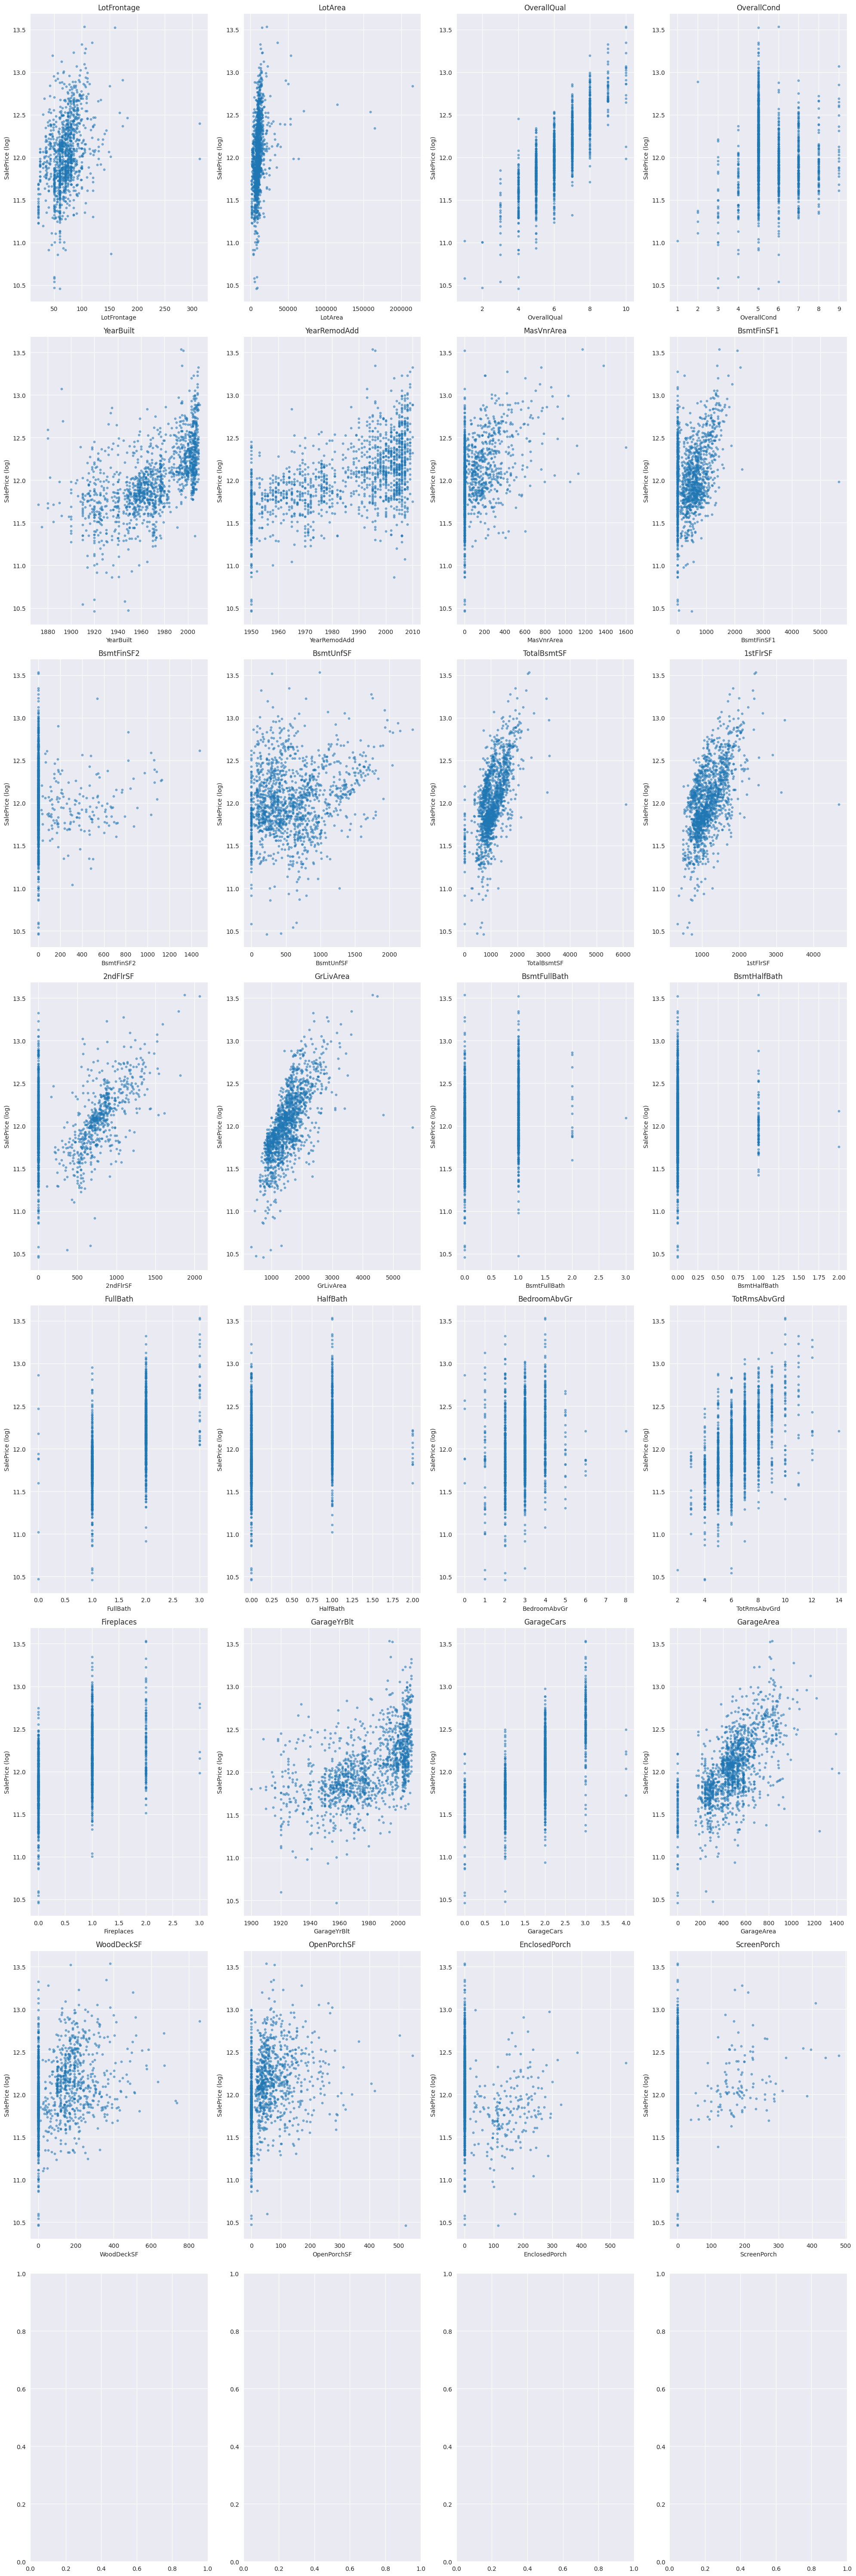

In [33]:
# outliers visualisation
numeric_cols = train_clean.select_dtypes(include=np.number).columns.tolist()

# plot each numeric column vs SalePrice
fig, axes = plt.subplots(nrows=len(numeric_cols)//4 + 1, ncols=4, figsize=(20, 60))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(train_clean[col], y, alpha=0.5, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice (log)")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Outliers found: 16
      GrLivArea
118        3222
185        3608
197        3112
304        3493
496        3228
523        4676
608        3194
635        3395
691        4316
769        3279
798        3140
1169       3627
1182       4476
1268       3447
1298       5642
1353       3238
Their prices: [320000. 475000. 235000. 295000. 430000. 184750. 359100. 200000. 755000.
 538000. 485000. 625000. 745000. 381000. 160000. 410000.]


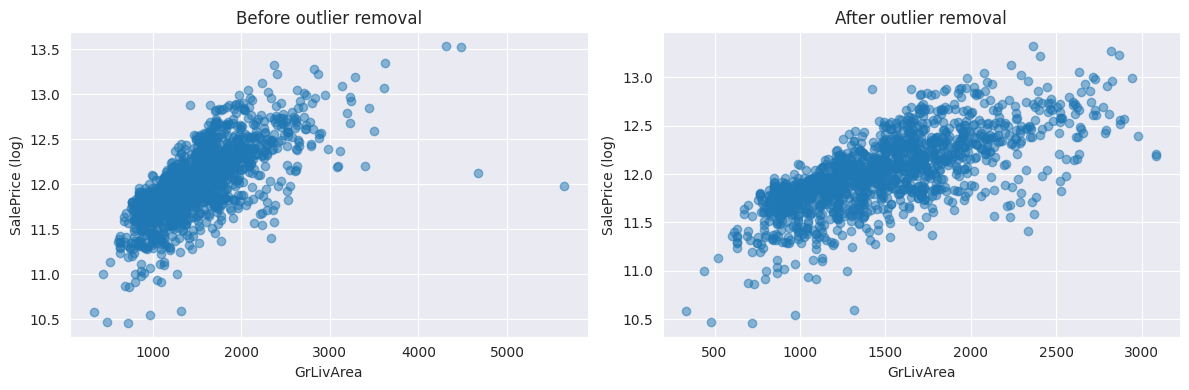


Train shape after removal: (1444, 63)


In [34]:
# removing outliers
# using Z-score method on GrLivArea

from scipy import stats

# calculate z-scores for GrLivArea only
z_scores = np.abs(stats.zscore(train_clean["GrLivArea"]))

# visualize before
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(train_clean["GrLivArea"], y, alpha=0.5)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice (log)")
plt.title("Before outlier removal")

# find outlier indices where z-score > 3
outlier_idx = train_clean[z_scores > 3].index
print(f"Outliers found: {len(outlier_idx)}")
print(train_clean.loc[outlier_idx, ["GrLivArea"]])
print(f"Their prices: {np.expm1(y[outlier_idx]).values}")

# remove from train only
train_clean = train_clean.drop(index=outlier_idx)
y = y.drop(index=outlier_idx)

# visualize after
plt.subplot(1, 2, 2)
plt.scatter(train_clean["GrLivArea"], y, alpha=0.5)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice (log)")
plt.title("After outlier removal")
plt.tight_layout()
plt.show()

print(f"\nTrain shape after removal: {train_clean.shape}")

In [35]:
# verify cleaning
print("=== train_clean ===")
print("Shape:", train_clean.shape)
print("Missing values:", train_clean.isnull().sum().sum())
print("Dtypes:\n", train_clean.dtypes.value_counts())

print("\n=== test_clean ===")
print("Shape:", test_clean.shape)
print("Missing values:", test_clean.isnull().sum().sum())

print("\n=== target (y) ===")
print("Shape:", y.shape)
print(y.describe())

=== train_clean ===
Shape: (1444, 63)
Missing values: 2246
Dtypes:
 object     35
int64      25
float64     3
Name: count, dtype: int64

=== test_clean ===
Shape: (1459, 63)
Missing values: 2335

=== target (y) ===
Shape: (1444,)
count    1444.000000
mean       12.015147
std         0.389494
min        10.460271
25%        11.773757
50%        11.995358
75%        12.268700
max        13.323929
Name: SalePrice, dtype: float64


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_clean, y,
    test_size=0.15,
    random_state=42
)

# Save processed targets
y_train.to_csv("../data/y_train.csv", index=False)
y_val.to_csv("../data/y_val.csv", index=False)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1227, 63)
X_val: (217, 63)
y_train: (1227,)
y_val: (217,)


In [41]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class HousePreprocessor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = X.copy()

        # 1. define nominal columns
        # must be before categorical_cols so we can exclude them
        self.nominal_cols = [
            "MSZoning", "LotConfig", "LandContour", "Neighborhood",
            "Condition1", "Condition2", "BldgType", "HouseStyle",
            "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd",
            "MasVnrType", "Foundation", "Heating", "CentralAir",
            "Electrical", "GarageType", "SaleType", "SaleCondition",
            "MSSubClass", "MoSold", "YrSold"
        ]
        self.nominal_cols = [c for c in self.nominal_cols if c in X.columns]

        # 2. learn medians for numerics
        self.numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
        self.numeric_medians = X[self.numeric_cols].median()

        # 3.learn categories
        # exclude nominal_cols — they get OHE, not mode-filled
        all_str_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
        self.categorical_cols = [
            c for c in all_str_cols if c not in self.nominal_cols
        ]
        if self.categorical_cols:
            self.categorical_modes = X[self.categorical_cols].mode().iloc[0]
        else:
            self.categorical_modes = {}

        # 4. learn ohe categories
        # learn from X_train only — prevents unseen categories
        self.ohe_categories_ = {}
        for col in self.nominal_cols:
            self.ohe_categories_[col] = X[col].dropna().unique().tolist()

        return self

    def transform(self, X):
        X = X.copy()

        # 1. fill NA's meaning none
        # NA here means house simply doesn't have that feature
        none_fill_cols = [
            "FireplaceQu",
            "GarageType", "GarageFinish", "GarageQual", "GarageCond",
            "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
            "MasVnrType"
        ]
        for col in none_fill_cols:
            if col in X.columns:
                X[col] = X[col].fillna("None")

        # 2. fill NA's meaning zero
        # NA here means no garage/basement = 0 area, 0 cars etc.
        zero_fill_cols = [
            "GarageYrBlt", "MasVnrArea",
            "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
            "BsmtFullBath", "BsmtHalfBath"
        ]
        for col in zero_fill_cols:
            if col in X.columns:
                X[col] = X[col].fillna(0)

        # ── STEP 3: FILL LOTFRONTAGE SMARTLY ─────────────
        # use neighborhood median — similar houses have similar lot size
        if "LotFrontage" in X.columns:
            X["LotFrontage"] = X.groupby("Neighborhood")["LotFrontage"].transform(
                lambda x: x.fillna(x.median())
            )
            # fallback: if whole neighborhood is missing, use global median
            X["LotFrontage"] = X["LotFrontage"].fillna(
                self.numeric_medians["LotFrontage"]
            )

        # ── STEP 4: FILL REMAINING NUMERIC NAs WITH MEDIAN
        for col in self.numeric_cols:
            if col in X.columns:
                X[col] = X[col].fillna(self.numeric_medians[col])

        # ── STEP 5: FILL REMAINING CATEGORICAL NAs WITH MODE
        for col in self.categorical_cols:
            if col in X.columns:
                X[col] = X[col].fillna(self.categorical_modes[col])

        # ── STEP 6: ORDINAL ENCODING ──────────────────────
        # these columns have a natural order (Po < Fa < TA < Gd < Ex)
        # so we encode them as numbers preserving that order
        quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
        quality_cols = [
            "ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
            "HeatingQC", "KitchenQual", "FireplaceQu",
            "GarageQual", "GarageCond"
        ]
        for col in quality_cols:
            if col in X.columns:
                X[col] = X[col].map(quality_map)

        if "BsmtExposure" in X.columns:
            X["BsmtExposure"] = X["BsmtExposure"].map(
                {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
            )
        if "BsmtFinType1" in X.columns:
            X["BsmtFinType1"] = X["BsmtFinType1"].map(
                {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
            )
        if "BsmtFinType2" in X.columns:
            X["BsmtFinType2"] = X["BsmtFinType2"].map(
                {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
            )
        if "GarageFinish" in X.columns:
            X["GarageFinish"] = X["GarageFinish"].map(
                {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
            )
        if "Functional" in X.columns:
            X["Functional"] = X["Functional"].map(
                {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4,
                 "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8}
            )
        if "LotShape" in X.columns:
            X["LotShape"] = X["LotShape"].map(
                {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4}
            )
        if "LandSlope" in X.columns:
            X["LandSlope"] = X["LandSlope"].map(
                {"Sev": 1, "Mod": 2, "Gtl": 3}
            )
        if "PavedDrive" in X.columns:
            X["PavedDrive"] = X["PavedDrive"].map(
                {"N": 0, "P": 1, "Y": 2}
            )

        # ── STEP 7: CREATE NEW FEATURES ───────────────────
        # combining existing columns into more meaningful features
        X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]

        X["TotalBaths"] = (
            X["FullBath"] + X["BsmtFullBath"] +
            X["HalfBath"] * 0.5 + X["BsmtHalfBath"] * 0.5
        )

        porch_cols = [c for c in ["OpenPorchSF", "EnclosedPorch",
                                   "3SsnPorch", "ScreenPorch"] if c in X.columns]
        X["TotalPorchSF"] = X[porch_cols].sum(axis=1)

        X["HouseAge"] = X["YrSold"].astype(int) - X["YearBuilt"]
        X["RemodAge"] = X["YrSold"].astype(int) - X["YearRemodAdd"]
        X["IsRemodeled"] = (X["YearRemodAdd"] != X["YearBuilt"]).astype(int)
        X["HasGarage"] = (X["GarageArea"] > 0).astype(int)
        X["HasBasement"] = (X["TotalBsmtSF"] > 0).astype(int)
        X["HasFireplace"] = (X["Fireplaces"] > 0).astype(int)
        if "PoolArea" in X.columns:
            X["HasPool"] = (X["PoolArea"] > 0).astype(int)

        # ── STEP 8: ONE-HOT ENCODING ──────────────────────
        # build all new columns first, then concat onc
        # avoids pandas fragmentation warning
        ohe_frames = []
        cols_to_drop_ohe = []

        for col in self.nominal_cols:
            if col in X.columns:
                for cat in self.ohe_categories_[col]:
                    ohe_frames.append(
                        (X[col] == cat).astype(int).rename(f"{col}_{cat}")
                    )
                cols_to_drop_ohe.append(col)

        X = X.drop(columns=cols_to_drop_ohe)

        if ohe_frames:
            X = pd.concat([X] + ohe_frames, axis=1)

        # ── STEP 9: FINAL SAFETY CHECK ────────────────────
        # drop any remaining string columns that slipped through
        remaining_str = X.select_dtypes(include=["object", "string"]).columns.tolist()
        if remaining_str:
            print(f"Warning: dropping remaining string cols: {remaining_str}")
            X = X.drop(columns=remaining_str)

        return X.copy()

In [42]:
# check which porch columns exist
porch_cols = [col for col in X_train.columns if "Porch" in col or "Ssn" in col]
print("Available porch columns:", porch_cols)

Available porch columns: ['OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']


In [43]:
# ── FIT ON X_TRAIN ONLY, TRANSFORM ALL THREE ─────────────
preprocessor = HousePreprocessor()

preprocessor.fit(X_train)  # learns medians/modes/categories from train only

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(test_clean)

X_train_processed.to_csv("../data/X_train_processed.csv", index=False)
X_val_processed.to_csv("../data/X_val_processed.csv", index=False)
X_test_processed.to_csv("../data/X_test_processed.csv", index=False)


print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

# verify no NAs remain
print("\nMissing in train:", X_train_processed.isnull().sum().sum())
print("Missing in val:", X_val_processed.isnull().sum().sum())
print("Missing in test:", X_test_processed.isnull().sum().sum())

X_train_processed shape: (1227, 218)
X_val_processed shape: (217, 218)
X_test_processed shape: (1459, 218)

Missing in train: 0
Missing in val: 0
Missing in test: 0
